# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

In [13]:
# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

# Load Dataset

In [7]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
Feature_5     0
Feature_6     0
Feature_7     0
Feature_8     0
Feature_9     0
Feature_10    0
Feature_11    0
Feature_12    0
Feature_13    0
Feature_14    0
Feature_15    0
Feature_16    0
Feature_17    0
Feature_18    0
Feature_19    0
Feature_20    0
Target        0
dtype: int64


In [6]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.010378,1.661880,0.006006,0.000614,-0.020328,1.006728,0.009196,0.060825,-0.008849,0.043310,...,-0.014650,0.973608,-0.974474,-0.993310,-0.611840,0.252620,-0.003153,-1.777044,-0.012840,0.025500
std,0.993861,6.196849,1.000003,2.058701,2.393185,2.122100,2.202713,2.207099,0.988001,2.199507,...,1.976415,2.143912,2.107014,2.013169,4.010733,4.080342,2.079566,4.594342,1.000356,0.157646
min,-3.744778,-21.173655,-3.999332,-7.405784,-10.966513,-6.640332,-7.750134,-8.425163,-3.563593,-6.947371,...,-6.511074,-7.227174,-10.269801,-8.554905,-17.500782,-17.331884,-7.067142,-17.809993,-3.794637,0.000000
25%,-0.653225,-2.494658,-0.659429,-1.406204,-1.639192,-0.396268,-1.529036,-1.411585,-0.690995,-1.507069,...,-1.394673,-0.489629,-2.385888,-2.213232,-2.978280,-2.322188,-1.411139,-4.989374,-0.708502,0.000000
50%,0.011950,1.815131,0.004138,-0.041269,-0.043324,1.002932,-0.038525,0.113480,-0.017874,-0.004226,...,-0.127989,0.968003,-0.983594,-1.033406,-0.498662,0.394616,0.001996,-1.684146,-0.022966,0.000000
75%,0.671564,5.903919,0.680942,1.386424,1.583272,2.420284,1.478532,1.571333,0.661276,1.513933,...,1.293780,2.415175,0.420049,0.225643,1.935521,3.028077,1.432315,1.493143,0.675057,0.000000
max,3.707905,22.292186,4.562115,7.872937,8.933525,8.706467,7.941155,8.972231,3.619986,9.170463,...,8.335624,9.605158,8.496091,7.503382,20.212769,14.402703,8.536054,13.786509,3.976868,1.000000


In [8]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 1081


In [9]:
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (283726, 31)


# Data Preprocessing

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (283726, 30)
Target Shape : (283726,)


In [14]:
# SCALING
scaler = StandardScaler()

X["Time"] = scaler.fit_transform(X[["Time"]])

X["Amount"] = scaler.fit_transform(X[["Amount"]])

X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813


# Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training Set:", X_train.shape)

print("Testing Set :", X_test.shape)

Training Set: (226980, 30)
Testing Set : (56746, 30)


# Baseline Model Training

# ~ Train Baseline Logistic Regression Model

In [16]:
baseline_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


# ~ Model Prediction

In [17]:
y_pred = baseline_model.predict(X_test)

print("Prediction Shape:", y_pred.shape)

Prediction Shape: (56746,)


# ~ Predicting Probabilities

In [18]:
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("First 10 Predicted Probabilities:")

print(y_prob[:10])

First 10 Predicted Probabilities:
[2.97738453e-04 2.77907028e-04 5.97633691e-05 9.93981437e-05
 1.29107123e-03 2.44807252e-04 8.51371174e-05 1.51722864e-04
 1.23743171e-04 1.60748915e-04]


# Baseline Evaluation Metrics

In [20]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df["Score"] = metrics_df["Score"].round(4)

metrics_df

,Metric,Score
0,Accuracy,0.9991
1,Precision,0.8485
2,Recall,0.5895
3,F1-Score,0.6957


# Custom ROC Curve Implementation

# A) Helper Function

In [21]:
def calculate_tpr_fpr(y_true, y_pred):
    """
    Calculate True Positive Rate (TPR)
    and False Positive Rate (FPR).
    """

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    tpr = TP / (TP + FN) if (TP + FN) != 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0

    return tpr, fpr

# B) Custom ROC Function

In [22]:
def custom_roc_curve(y_true, y_prob):

    thresholds = np.sort(np.unique(y_prob))[::-1]

    tpr_list = []
    fpr_list = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        tpr, fpr = calculate_tpr_fpr(y_true, y_pred)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list), thresholds

In [23]:
fpr, tpr, thresholds = custom_roc_curve(
    y_test.values,
    y_prob
)

print("Number of Thresholds:", len(thresholds))

Number of Thresholds: 56746


# C) Compute ROC-AUC

In [24]:
sorted_idx = np.argsort(fpr)

roc_auc = np.trapz(
    tpr[sorted_idx],
    fpr[sorted_idx]
)

print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.9584


# D) Plot ROC Curve

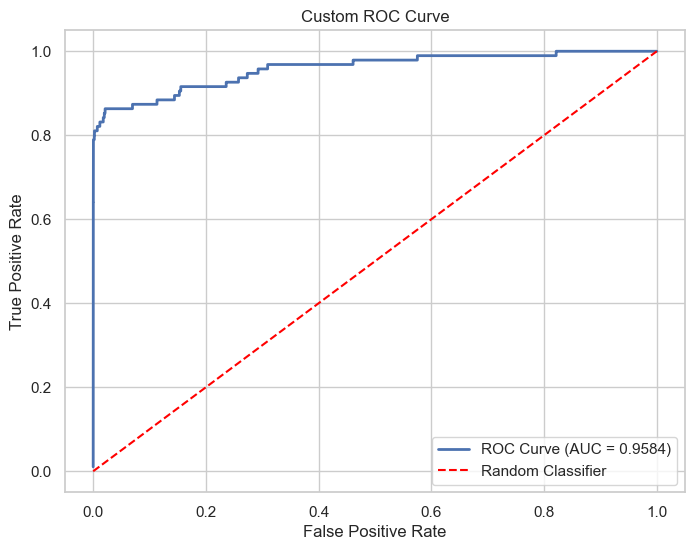

In [25]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Custom ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Custom Precision Recall Curve

# A) Helper Function

In [26]:
def calculate_precision_recall(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))

    FP = np.sum((y_true == 0) & (y_pred == 1))

    FN = np.sum((y_true == 1) & (y_pred == 0))

    precision = TP / (TP + FP) if (TP + FP) != 0 else 1

    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    return precision, recall

# B) Custom PR Curve Function

In [27]:
def custom_precision_recall_curve(y_true, y_prob):

    thresholds = np.sort(np.unique(y_prob))[::-1]

    precision_list = []

    recall_list = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision, recall = calculate_precision_recall(
            y_true,
            y_pred
        )

        precision_list.append(precision)

        recall_list.append(recall)

    return (
        np.array(precision_list),
        np.array(recall_list),
        thresholds
    )

In [28]:
precision_values, recall_values, pr_thresholds = custom_precision_recall_curve(
    y_test.values,
    y_prob
)

print("Thresholds:", len(pr_thresholds))

Thresholds: 56746


# C) Compute PR-AUC

In [29]:
sorted_idx = np.argsort(recall_values)

pr_auc = np.trapz(
    precision_values[sorted_idx],
    recall_values[sorted_idx]
)

print(f"PR AUC Score: {pr_auc:.4f}")

PR AUC Score: 0.6801


# D) Plot PR Curve

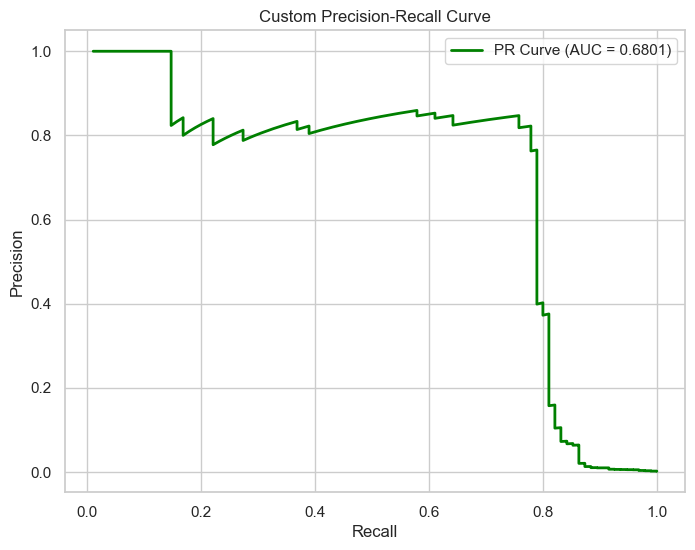

In [30]:
plt.figure(figsize=(8,6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    color="green",
    label=f"PR Curve (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Custom Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

# Threshold Analysis

In [31]:
thresholds = np.arange(0.1, 1.0, 0.1)
thresholds

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [32]:
# Evaluate Different Thresholds

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)

    recall = recall_score(y_test, y_pred_threshold, zero_division=0)

    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.1,0.843373,0.736842,0.786517
1,0.2,0.835443,0.694737,0.758621
2,0.3,0.845070,0.631579,0.722892
3,0.4,0.852941,0.610526,0.711656
4,0.5,0.848485,0.589474,0.695652
5,0.6,0.859375,0.578947,0.691824
6,0.7,0.850000,0.536842,0.658065
7,0.8,0.836364,0.484211,0.613333
8,0.9,0.826923,0.452632,0.585034


# Combined Precision vs Recall vs Threshold Plot

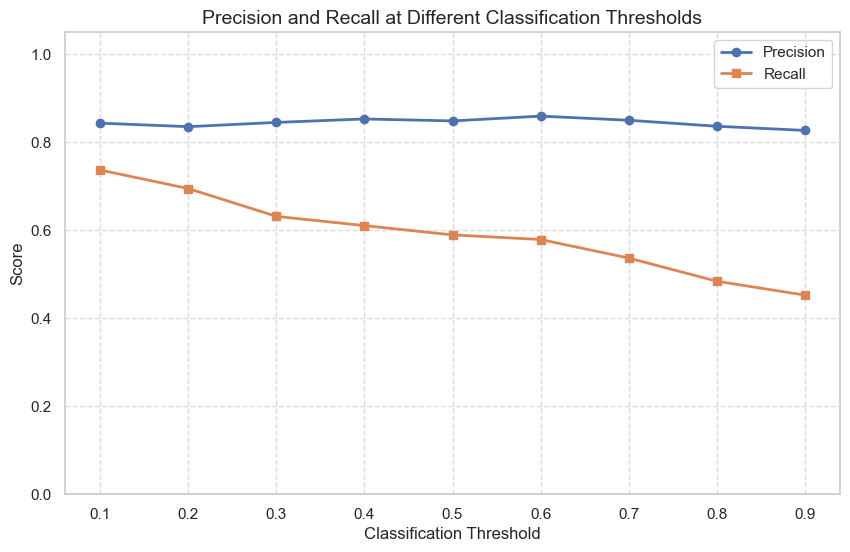

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

plt.xlabel("Classification Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Precision and Recall at Different Classification Thresholds", fontsize=14)

plt.xticks(threshold_df["Threshold"])
plt.ylim(0, 1.05)

plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.show()
plt.show()

# Comparison of Macro, Micro, and Weighted F1-Scores

In [35]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

micro_f1 = f1_score(
    y_test,
    y_pred,
    average="micro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

In [36]:
f1_comparison = pd.DataFrame({
    "Averaging Method": [
        "Macro",
        "Micro",
        "Weighted"
    ],
    "F1-Score": [
        macro_f1,
        micro_f1,
        weighted_f1
    ]
})

f1_comparison["F1-Score"] = f1_comparison["F1-Score"].round(4)

f1_comparison

,Averaging Method,F1-Score
0,Macro,0.8476
1,Micro,0.9991
2,Weighted,0.9991
